# Kaggle Leukemia CNN+GNN

Self-contained notebook for the Kaggle leukemia classification dataset. No project Python modules are imported; all model, training, metric, and Grad-CAM code is inside this notebook.

In [1]:

from __future__ import annotations

import copy
import json
import math
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image, ImageDraw, ImageFilter, ImageFont
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms

SEED = 42
IMAGE_SIZE = int(os.getenv("KAGGLE_IMAGE_SIZE", "96"))
BATCH_SIZE = int(os.getenv("KAGGLE_BATCH_SIZE", "128"))
EPOCHS = int(os.getenv("KAGGLE_EPOCHS", "100"))
PATIENCE = int(os.getenv("KAGGLE_PATIENCE", str(EPOCHS)))
LEARNING_RATE = float(os.getenv("KAGGLE_LR", "4e-4"))
WEIGHT_DECAY = float(os.getenv("KAGGLE_WEIGHT_DECAY", "1e-4"))
NUM_THREADS = min(8, max(1, os.cpu_count() or 1))
torch.set_num_threads(NUM_THREADS)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATASET_ROOT = PROJECT_ROOT / "data/raw/kaggle_leukemia_classification/kagglehub_cache/datasets/andrewmvd/leukemia-classification/versions/2/C-NMC_Leukemia"
CLASS_NAMES = ["hem", "all"]
DISPLAY_NAMES = {"hem": "healthy", "all": "leukemia"}
LABEL_TO_NAME = {0: "hem", 1: "all"}
NAME_TO_LABEL = {v: k for k, v in LABEL_TO_NAME.items()}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATASET_ROOT)
print("Device:", DEVICE)
print("CPU threads:", NUM_THREADS)
print("Image size:", IMAGE_SIZE, "Batch size:", BATCH_SIZE, "Epochs:", EPOCHS)
print("Backbone: compact ResNet-style residual CNN trained on Kaggle C-NMC only")


Project root: /Users/panshulaj/Documents/AIML proj
Dataset root: /Users/panshulaj/Documents/AIML proj/data/raw/kaggle_leukemia_classification/kagglehub_cache/datasets/andrewmvd/leukemia-classification/versions/2/C-NMC_Leukemia
Device: mps
CPU threads: 8
Image size: 96 Batch size: 128 Epochs: 100
Backbone: compact ResNet-style residual CNN trained on Kaggle C-NMC only


## Dataset Inventory

The code below uses the extracted Kaggle dataset only and verifies labeled counts before training.

In [2]:

def patient_id_from_original_name(name: str) -> str:
    stem = Path(name).stem
    parts = stem.split("_")
    if len(parts) >= 2 and parts[0].lower() == "uid":
        return parts[1]
    return parts[0]


def build_training_frame(dataset_root: Path) -> pd.DataFrame:
    rows = []
    train_root = dataset_root / "training_data"
    for fold_dir in sorted(train_root.glob("fold_*")):
        for class_name, label in NAME_TO_LABEL.items():
            class_dir = fold_dir / class_name
            for path in sorted(class_dir.glob("*.bmp")):
                rows.append(
                    {
                        "path": str(path.resolve()),
                        "label": label,
                        "class_name": class_name,
                        "display_class": DISPLAY_NAMES[class_name],
                        "patient_id": patient_id_from_original_name(path.name),
                        "source_split": "training_data",
                        "source_fold": fold_dir.name,
                    }
                )
    return pd.DataFrame(rows)


def build_test_frame(dataset_root: Path) -> pd.DataFrame:
    labels_path = dataset_root / "validation_data" / "C-NMC_test_prelim_phase_data_labels.csv"
    image_dir = dataset_root / "validation_data" / "C-NMC_test_prelim_phase_data"
    labels = pd.read_csv(labels_path)
    rows = []
    for row in labels.itertuples(index=False):
        label = int(row.labels)
        class_name = LABEL_TO_NAME[label]
        path = image_dir / str(row.new_names)
        rows.append(
            {
                "path": str(path.resolve()),
                "label": label,
                "class_name": class_name,
                "display_class": DISPLAY_NAMES[class_name],
                "patient_id": patient_id_from_original_name(str(row.Patient_ID)),
                "source_split": "validation_data_labeled_test",
                "source_fold": "prelim_phase",
                "original_name": str(row.Patient_ID),
            }
        )
    return pd.DataFrame(rows)


train_full = build_training_frame(DATASET_ROOT)
test_df = build_test_frame(DATASET_ROOT)
unlabeled_final_dir = DATASET_ROOT / "testing_data" / "C-NMC_test_final_phase_data"
unlabeled_final_count = len(list(unlabeled_final_dir.glob("*.bmp")))

patient_table = train_full.groupby("patient_id", as_index=False)["label"].first()
train_patients, val_patients = train_test_split(
    patient_table,
    test_size=0.15,
    random_state=SEED,
    stratify=patient_table["label"],
)
train_df = train_full[train_full["patient_id"].isin(set(train_patients["patient_id"]))].reset_index(drop=True)
val_df = train_full[train_full["patient_id"].isin(set(val_patients["patient_id"]))].reset_index(drop=True)

summary = pd.DataFrame(
    {
        "split": ["train", "val", "labeled_test", "unlabeled_final_ignored"],
        "images": [len(train_df), len(val_df), len(test_df), unlabeled_final_count],
        "healthy_hem": [int((train_df.label == 0).sum()), int((val_df.label == 0).sum()), int((test_df.label == 0).sum()), None],
        "leukemia_all": [int((train_df.label == 1).sum()), int((val_df.label == 1).sum()), int((test_df.label == 1).sum()), None],
        "patient_groups": [train_df.patient_id.nunique(), val_df.patient_id.nunique(), test_df.patient_id.nunique(), None],
    }
)
display(summary)

assert DATASET_ROOT.exists(), f"Missing dataset root: {DATASET_ROOT}"
assert len(train_full) == 10661, f"Expected 10661 training images, found {len(train_full)}"
assert len(test_df) == 1867, f"Expected 1867 labeled validation/test images, found {len(test_df)}"
assert train_df["path"].map(lambda p: Path(p).exists()).all()
assert val_df["path"].map(lambda p: Path(p).exists()).all()
assert test_df["path"].map(lambda p: Path(p).exists()).all()


,split,images,healthy_hem,leukemia_all,patient_groups
0,train,8958,2742.0,6216.0,62.0
1,val,1703,647.0,1056.0,11.0
2,labeled_test,1867,648.0,1219.0,28.0
3,unlabeled_final_ignored,2586,NaN,NaN,NaN


## Preprocessing and DataLoaders

Images are white-balanced, contrast-stretched, resized, augmented for training, normalized from the training split only, and sampled with class balancing.

In [3]:

class MicroscopyPreprocess:
    """Deterministic stain/illumination normalization for cell crops."""

    def __init__(self, low: float = 0.5, high: float = 99.5, gamma: float = 0.95, sharpen: bool = True):
        self.low = low
        self.high = high
        self.gamma = gamma
        self.sharpen = sharpen

    def __call__(self, image: Image.Image) -> Image.Image:
        arr = np.asarray(image.convert("RGB"), dtype=np.float32) / 255.0
        channel_means = arr.reshape(-1, 3).mean(axis=0, keepdims=True)
        gray_mean = channel_means.mean()
        arr = arr * (gray_mean / np.maximum(channel_means, 1e-4)).reshape(1, 1, 3)
        lo = np.percentile(arr, self.low, axis=(0, 1), keepdims=True)
        hi = np.percentile(arr, self.high, axis=(0, 1), keepdims=True)
        arr = (arr - lo) / np.maximum(hi - lo, 1e-4)
        arr = np.clip(arr, 0.0, 1.0)
        arr = np.power(arr, self.gamma)
        out = Image.fromarray((arr * 255).astype(np.uint8))
        if self.sharpen:
            out = out.filter(ImageFilter.UnsharpMask(radius=1.0, percent=110, threshold=3))
        return out


class RandomGaussianNoise:
    def __init__(self, std: float = 0.010, p: float = 0.20):
        self.std = std
        self.p = p

    def __call__(self, tensor: torch.Tensor) -> torch.Tensor:
        if random.random() >= self.p:
            return tensor
        return torch.clamp(tensor + torch.randn_like(tensor) * self.std, 0.0, 1.0)


base_preprocess = transforms.Compose([
    MicroscopyPreprocess(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.BICUBIC),
])


def image_to_uint8_tensor(image: Image.Image) -> torch.Tensor:
    arr = np.asarray(base_preprocess(image).convert("RGB"), dtype=np.uint8)
    return torch.from_numpy(arr).permute(2, 0, 1).contiguous()


def cache_uint8_images(frame: pd.DataFrame, name: str) -> list[torch.Tensor]:
    cached = []
    total = len(frame)
    for index, row in enumerate(frame.itertuples(index=False), start=1):
        with Image.open(row.path) as image:
            cached.append(image_to_uint8_tensor(image))
        if index == 1 or index == total or index % 1000 == 0:
            print(f"cached {name}: {index}/{total}", flush=True)
    return cached


def compute_mean_std_from_cache(cache: list[torch.Tensor]) -> tuple[list[float], list[float]]:
    channel_sum = torch.zeros(3)
    channel_sq_sum = torch.zeros(3)
    pixels = 0
    for byte_tensor in cache:
        tensor = byte_tensor.float().div(255.0)
        channel_sum += tensor.sum(dim=(1, 2))
        channel_sq_sum += (tensor ** 2).sum(dim=(1, 2))
        pixels += tensor.shape[1] * tensor.shape[2]
    mean = channel_sum / pixels
    variance = channel_sq_sum / pixels - mean ** 2
    std = torch.sqrt(torch.clamp(variance, min=1e-8))
    return mean.tolist(), std.tolist()


train_cache = cache_uint8_images(train_df, "train")
val_cache = cache_uint8_images(val_df, "val")
test_cache = cache_uint8_images(test_df, "labeled_test")
mean, std = compute_mean_std_from_cache(train_cache)
print("Train normalization mean:", [round(x, 6) for x in mean])
print("Train normalization std:", [round(x, 6) for x in std])

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.76, 1.0),
        ratio=(0.92, 1.08),
        interpolation=transforms.InterpolationMode.BILINEAR,
        antialias=True,
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.06, 0.06),
        scale=(0.92, 1.10),
        shear=4,
        interpolation=transforms.InterpolationMode.BILINEAR,
    ),
    transforms.RandomAutocontrast(p=0.30),
    transforms.RandomAdjustSharpness(sharpness_factor=1.5, p=0.20),
    transforms.ColorJitter(brightness=0.16, contrast=0.16, saturation=0.10, hue=0.012),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.7))], p=0.08),
    RandomGaussianNoise(std=0.010, p=0.20),
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomErasing(p=0.14, scale=(0.012, 0.045), ratio=(0.5, 2.0), value=0.0),
])

eval_transform = transforms.Compose([
    transforms.Normalize(mean=mean, std=std),
])

plain_transform = transforms.Compose([])


class LeukemiaDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, cached_images: list[torch.Tensor], transform=None):
        self.frame = frame.reset_index(drop=True)
        self.cached_images = cached_images
        self.transform = transform

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        row = self.frame.iloc[index]
        image = self.cached_images[index].float().div(255.0)
        if self.transform is not None:
            image = self.transform(image)
        return image, int(row.label), row.path


train_counts = train_df["label"].value_counts().sort_index()
sample_weights = train_df["label"].map(lambda label: 1.0 / train_counts[int(label)]).to_numpy()
sampler_generator = torch.Generator().manual_seed(SEED)
sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator=sampler_generator,
)

train_dataset = LeukemiaDataset(train_df, train_cache, train_transform)
val_dataset = LeukemiaDataset(val_df, val_cache, eval_transform)
test_dataset = LeukemiaDataset(test_df, test_cache, eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY,
)

batch_images, batch_labels, batch_paths = next(iter(train_loader))
print("Batch tensor:", tuple(batch_images.shape), "Batch labels:", batch_labels[:8].tolist())


cached train: 1/8958


/var/folders/fn/y2r7tz8s7m988x6s6msf6ndr0000gn/T/ipykernel_10547/995016779.py:45: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  return torch.from_numpy(arr).permute(2, 0, 1).contiguous()


cached train: 1000/8958


cached train: 2000/8958


cached train: 3000/8958


...

cached labeled_test: 1/1867


cached labeled_test: 1000/1867


cached labeled_test: 1867/1867


Train normalization mean: [0.124185, 0.095022, 0.132939]
Train normalization std: [0.279825, 0.218818, 0.2982]


Batch tensor: (128, 3, 96, 96) Batch labels: [0, 0, 0, 0, 0, 0, 1, 1]


## Compact ResNet CNN+GNN Architecture

This model uses a compact ResNet-style residual CNN backbone trained on the Kaggle C-NMC images, projects the residual feature map into graph nodes, and applies gated spatial graph blocks before classification. No external pretrained image weights are used.

In [4]:

class ResidualBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1, dropout: float = 0.04):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.act = nn.GELU()
        self.dropout = nn.Dropout2d(dropout)
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.shortcut(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        return self.act(out + identity)


class CompactResNetBackbone(nn.Module):
    def __init__(self, channels: tuple[int, int, int, int] = (32, 64, 128, 192)):
        super().__init__()
        c1, c2, c3, c4 = channels
        self.stem = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c1),
            nn.GELU(),
        )
        self.stage1 = nn.Sequential(ResidualBlock(c1, c1), ResidualBlock(c1, c1))
        self.stage2 = nn.Sequential(ResidualBlock(c1, c2, stride=2), ResidualBlock(c2, c2))
        self.stage3 = nn.Sequential(ResidualBlock(c2, c3, stride=2), ResidualBlock(c3, c3))
        self.stage4 = nn.Sequential(ResidualBlock(c3, c4, stride=2), ResidualBlock(c4, c4))
        self.out_channels = c4

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return x


class SpatialGraphBlock(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.18):
        super().__init__()
        self.self_proj = nn.Linear(dim, dim)
        self.neighbor_proj = nn.Linear(dim, dim)
        self.gate = nn.Sequential(nn.Linear(dim * 2, dim), nn.Sigmoid())
        self.norm1 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 3),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 3, dim),
        )
        self.norm2 = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, nodes: torch.Tensor, adjacency: torch.Tensor) -> torch.Tensor:
        neighbor_nodes = torch.matmul(adjacency, nodes)
        update = torch.nn.functional.gelu(self.self_proj(nodes) + self.neighbor_proj(neighbor_nodes))
        gate = self.gate(torch.cat([nodes, neighbor_nodes], dim=-1))
        nodes = self.norm1(nodes + self.dropout(gate * update))
        nodes = self.norm2(nodes + self.dropout(self.ffn(nodes)))
        return nodes


class CNNGNN(nn.Module):
    def __init__(self, image_size: int = IMAGE_SIZE, embed_dim: int = 96, gnn_layers: int = 3, num_classes: int = 2):
        super().__init__()
        self.backbone = CompactResNetBackbone()
        self.target_layer = self.backbone.stage4
        with torch.no_grad():
            features = self.backbone(torch.zeros(1, 3, image_size, image_size))
        self.feature_shape = (int(features.shape[-2]), int(features.shape[-1]))
        self.projection = nn.Sequential(
            nn.Conv2d(self.backbone.out_channels, embed_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(embed_dim),
            nn.GELU(),
        )
        self.gnn = nn.ModuleList([SpatialGraphBlock(embed_dim, dropout=0.18) for _ in range(gnn_layers)])
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim * 2),
            nn.Linear(embed_dim * 2, embed_dim),
            nn.GELU(),
            nn.Dropout(0.30),
            nn.Linear(embed_dim, num_classes),
        )
        self._adjacency_cache = {}

    def adjacency(self, height: int, width: int, device: torch.device) -> torch.Tensor:
        key = (height, width, str(device))
        if key in self._adjacency_cache:
            return self._adjacency_cache[key]
        node_count = height * width
        adjacency = torch.zeros(node_count, node_count, device=device)
        for y in range(height):
            for x in range(width):
                i = y * width + x
                for dy in (-1, 0, 1):
                    for dx in (-1, 0, 1):
                        ny, nx = y + dy, x + dx
                        if 0 <= ny < height and 0 <= nx < width:
                            j = ny * width + nx
                            adjacency[i, j] = 1.0
        adjacency = adjacency / adjacency.sum(dim=1, keepdim=True).clamp_min(1.0)
        self._adjacency_cache[key] = adjacency
        return adjacency

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone(x)
        features = self.projection(features)
        batch, channels, height, width = features.shape
        nodes = features.flatten(2).transpose(1, 2)
        adjacency = self.adjacency(height, width, features.device)
        for layer in self.gnn:
            nodes = layer(nodes, adjacency)
        pooled = torch.cat([nodes.mean(dim=1), nodes.max(dim=1).values], dim=1)
        return self.head(pooled)


model = CNNGNN().to(DEVICE)
print(model)
print("Feature map for graph/tokens:", model.feature_shape)
print("Graph nodes per image:", model.feature_shape[0] * model.feature_shape[1])
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


CNNGNN(
  (backbone): CompactResNetBackbone(
    (stem): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): GELU(approximate='none')
    )
    (stage1): Sequential(
      (0): ResidualBlock(
        (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (act): GELU(approximate='none')
        (dropout): Dropout2d(p=0.04, inplace=False)
        (shortcut): Identity()
      )
      (1): ResidualBlock(
        (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=

## Training, Evaluation, and Grad-CAM

The best validation-balanced checkpoint from this notebook run is evaluated on the labeled Kaggle validation split, then Grad-CAM overlays are generated for selected mistakes and correct examples.

In [5]:

def class_weights_from_frame(frame: pd.DataFrame) -> torch.Tensor:
    counts = frame["label"].value_counts().sort_index().to_numpy(dtype=np.float32)
    weights = counts.sum() / (len(counts) * counts)
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def forward_with_tta(model: nn.Module, images: torch.Tensor) -> torch.Tensor:
    variants = [
        images,
        torch.flip(images, dims=[3]),
        torch.flip(images, dims=[2]),
        torch.flip(images, dims=[2, 3]),
    ]
    logits = [model(variant) for variant in variants]
    return torch.stack(logits, dim=0).mean(dim=0)


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module | None = None, use_tta: bool = False) -> dict:
    model.eval()
    losses = []
    y_true, y_prob, paths = [], [], []
    for images, labels, batch_paths in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        logits = forward_with_tta(model, images) if use_tta else model(images)
        if criterion is not None:
            losses.append(float(criterion(logits, labels).detach().cpu()))
        probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        y_prob.extend(probs.tolist())
        y_true.extend(labels.detach().cpu().numpy().tolist())
        paths.extend(list(batch_paths))
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "loss": float(np.mean(losses)) if losses else np.nan,
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "paths": paths,
    }


def state_dict_to_cpu(model: nn.Module) -> dict[str, torch.Tensor]:
    return {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}


def train_one_epoch(model: nn.Module, loader: DataLoader, criterion: nn.Module, optimizer: torch.optim.Optimizer) -> dict:
    model.train()
    losses = []
    y_true, y_pred = [], []
    for images, labels, _ in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(logits.argmax(dim=1).detach().cpu().numpy().tolist())
    return {"loss": float(np.mean(losses)), "accuracy": accuracy_score(y_true, y_pred)}


def best_threshold(y_true: np.ndarray, y_prob: np.ndarray) -> tuple[float, float]:
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = [balanced_accuracy_score(y_true, (y_prob >= threshold).astype(int)) for threshold in thresholds]
    index = int(np.argmax(scores))
    return float(thresholds[index]), float(scores[index])


def summarize_predictions(y_true: np.ndarray, y_prob: np.ndarray, threshold: float) -> tuple[dict, np.ndarray]:
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "threshold": float(threshold),
        "samples": int(len(y_true)),
        "hem_healthy_support": int((y_true == 0).sum()),
        "all_leukemia_support": int((y_true == 1).sum()),
        "confusion_hem_hem": int(cm[0, 0]),
        "confusion_hem_all": int(cm[0, 1]),
        "confusion_all_hem": int(cm[1, 0]),
        "confusion_all_all": int(cm[1, 1]),
    }
    return metrics, y_pred


def fit_model(model: nn.Module, out_dir: Path) -> tuple[nn.Module, pd.DataFrame, dict, pd.DataFrame]:
    out_dir.mkdir(parents=True, exist_ok=True)
    metrics_path = out_dir / "metrics.json"
    history_path = out_dir / "training_history.csv"
    predictions_path = out_dir / "predictions.csv"
    state_path = out_dir / "best_model_state.pt"
    if metrics_path.exists() and history_path.exists() and predictions_path.exists() and state_path.exists():
        metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
        history_df = pd.read_csv(history_path)
        if int(metrics.get("epochs_requested", -1)) == EPOCHS and int(metrics.get("epochs_ran", -1)) == EPOCHS and len(history_df) == EPOCHS:
            print(f"Using completed saved {EPOCHS}-epoch run from: {out_dir}", flush=True)
            state = torch.load(state_path, map_location="cpu")
            model.load_state_dict({key: value.to(DEVICE) for key, value in state.items()})
            predictions = pd.read_csv(predictions_path)
            return model, history_df, metrics, predictions
    criterion = nn.CrossEntropyLoss(weight=class_weights_from_frame(train_df), label_smoothing=0.03)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(1, EPOCHS),
        eta_min=LEARNING_RATE * 0.03,
    )

    best_state = state_dict_to_cpu(model)
    best_score = -1.0
    best_epoch = 0
    best_val_threshold = 0.5
    history = []
    wait = 0
    start = time.time()

    for epoch in range(1, EPOCHS + 1):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer)
        val_eval = evaluate(model, val_loader, criterion, use_tta=False)
        threshold, val_balanced = best_threshold(val_eval["y_true"], val_eval["y_prob"])
        val_pred = (val_eval["y_prob"] >= threshold).astype(int)
        val_accuracy = accuracy_score(val_eval["y_true"], val_pred)
        scheduler.step()
        lr = optimizer.param_groups[0]["lr"]
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "val_loss": val_eval["loss"],
                "val_accuracy": float(val_accuracy),
                "val_balanced_accuracy": float(val_balanced),
                "val_threshold": float(threshold),
                "learning_rate": float(lr),
            }
        )
        pd.DataFrame(history).to_csv(out_dir / "training_history_live.csv", index=False)
        print(
            f"epoch {epoch:03d}/{EPOCHS} "
            f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['accuracy']:.4f} "
            f"val_loss={val_eval['loss']:.4f} val_acc={val_accuracy:.4f} "
            f"val_bal={val_balanced:.4f} thr={threshold:.3f} lr={lr:.2e}",
            flush=True,
        )
        if val_balanced > best_score:
            best_score = float(val_balanced)
            best_epoch = epoch
            best_val_threshold = float(threshold)
            best_state = state_dict_to_cpu(model)
            torch.save(best_state, out_dir / "best_model_state.pt")
            wait = 0
        else:
            wait += 1
        if wait >= PATIENCE:
            print(f"Early stop at epoch {epoch}; best epoch was {best_epoch}.", flush=True)
            break

    model.load_state_dict({key: value.to(DEVICE) for key, value in best_state.items()})
    final_val_eval = evaluate(model, val_loader, criterion, use_tta=True)
    final_threshold, final_val_balanced = best_threshold(final_val_eval["y_true"], final_val_eval["y_prob"])
    test_eval = evaluate(model, test_loader, criterion, use_tta=True)
    test_metrics, test_pred = summarize_predictions(test_eval["y_true"], test_eval["y_prob"], final_threshold)
    test_metrics.update(
        {
            "backbone": "compact_resnet_residual_cnn",
            "preprocessing": "gray_world_percentile_contrast_gamma_unsharp_cached_uint8_tensor_aug_flip_rotate_affine_jitter_blur_noise_erasing_tta",
            "best_epoch": int(best_epoch),
            "best_validation_balanced_accuracy": float(best_score),
            "best_validation_threshold": float(best_val_threshold),
            "tta_validation_balanced_accuracy": float(final_val_balanced),
            "tta_validation_threshold": float(final_threshold),
            "tta_flips_used_for_final_eval": 4,
            "train_images": int(len(train_df)),
            "val_images": int(len(val_df)),
            "test_images": int(len(test_df)),
            "epochs_requested": int(EPOCHS),
            "epochs_ran": int(len(history)),
            "elapsed_seconds": float(time.time() - start),
            "device": str(DEVICE),
            "dataset_root": str(DATASET_ROOT.resolve()),
            "unlabeled_final_images_not_scored": int(unlabeled_final_count),
        }
    )
    predictions = pd.DataFrame(
        {
            "path": test_eval["paths"],
            "true_label": test_eval["y_true"],
            "true_class": [LABEL_TO_NAME[int(x)] for x in test_eval["y_true"]],
            "predicted_label": test_pred,
            "predicted_class": [LABEL_TO_NAME[int(x)] for x in test_pred],
            "probability_all_leukemia": test_eval["y_prob"],
            "is_correct": test_pred == test_eval["y_true"],
        }
    )
    history_df = pd.DataFrame(history)
    history_df.to_csv(out_dir / "training_history.csv", index=False)
    predictions.to_csv(out_dir / "predictions.csv", index=False)
    (out_dir / "metrics.json").write_text(json.dumps(test_metrics, indent=2), encoding="utf-8")
    pd.Series(test_metrics).to_frame("value").to_csv(out_dir / "metrics.csv")
    return model, history_df, test_metrics, predictions


In [6]:

def plot_training_history(history_df: pd.DataFrame, out_dir: Path) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="train acc")
    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="val acc")
    axes[1].plot(history_df["epoch"], history_df["val_balanced_accuracy"], label="val balanced")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(out_dir / "training_history.png", dpi=160)
    plt.show()


def plot_confusion_and_roc(metrics: dict, predictions: pd.DataFrame, out_dir: Path) -> None:
    cm = np.array([
        [metrics["confusion_hem_hem"], metrics["confusion_hem_all"]],
        [metrics["confusion_all_hem"], metrics["confusion_all_all"]],
    ])
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(cm, cmap="Blues")
    axes[0].set_xticks([0, 1], ["hem", "all"])
    axes[0].set_yticks([0, 1], ["hem", "all"])
    axes[0].set_xlabel("predicted")
    axes[0].set_ylabel("true")
    axes[0].set_title("Confusion Matrix")
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
    fpr, tpr, _ = roc_curve(predictions["true_label"], predictions["probability_all_leukemia"])
    axes[1].plot(fpr, tpr, label=f"ROC-AUC={metrics['roc_auc']:.4f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1].set_xlabel("False positive rate")
    axes[1].set_ylabel("True positive rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(out_dir / "confusion_roc.png", dpi=160)
    plt.show()


class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(self._forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def close(self) -> None:
        self.forward_handle.remove()
        self.backward_handle.remove()

    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc, tb):
        self.close()

    def __call__(self, tensor: torch.Tensor, class_index: int | None = None) -> tuple[np.ndarray, np.ndarray, int]:
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        logits = self.model(tensor.to(DEVICE))
        probabilities = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()
        if class_index is None:
            class_index = int(np.argmax(probabilities))
        score = logits[:, class_index].sum()
        score.backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = torch.nn.functional.interpolate(cam, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False)
        cam = cam[0, 0].detach().cpu().numpy()
        cam = (cam - cam.min()) / max(float(cam.max() - cam.min()), 1e-8)
        return cam, probabilities, class_index


def heatmap_overlay(image: Image.Image, cam: np.ndarray, alpha: float = 0.42) -> Image.Image:
    base = plain_transform(image).convert("RGB")
    cmap = plt.get_cmap("jet")
    heatmap = (cmap(cam)[:, :, :3] * 255).astype(np.uint8)
    heatmap_image = Image.fromarray(heatmap).resize(base.size, Image.Resampling.BILINEAR)
    return Image.blend(base, heatmap_image, alpha=alpha)


def make_gradcam_sheet(model: nn.Module, predictions: pd.DataFrame, out_dir: Path, max_images: int = 12) -> Path:
    errors = predictions[~predictions["is_correct"]].head(max_images // 2)
    correct = predictions[predictions["is_correct"]].groupby("true_label", group_keys=False).head(max_images // 4)
    chosen = pd.concat([errors, correct], ignore_index=True).head(max_images)
    if chosen.empty:
        chosen = predictions.head(max_images)

    tiles = []
    manifest = []
    with GradCAM(model, model.target_layer) as gradcam:
        for row in chosen.itertuples(index=False):
            path = Path(row.path)
            with Image.open(path) as image:
                image = image.convert("RGB")
                processed = base_preprocess(image).convert("RGB")
                tensor = torch.from_numpy(np.asarray(processed, dtype=np.uint8)).permute(2, 0, 1).contiguous().float().div(255.0)
                tensor = eval_transform(tensor).unsqueeze(0)
                cam, probs, target_class = gradcam(tensor, class_index=int(row.predicted_label))
                overlay = heatmap_overlay(processed, cam)
            title = f"{path.name}\ntrue={row.true_class} pred={row.predicted_class}\np(all)={row.probability_all_leukemia:.3f}"
            tiles.append((overlay, title))
            overlay_path = out_dir / f"gradcam_{path.stem}_true-{row.true_class}_pred-{row.predicted_class}.png"
            overlay.save(overlay_path)
            manifest.append({"path": str(path), "overlay": str(overlay_path), "title": title})

    tile_w, tile_h = IMAGE_SIZE * 2, IMAGE_SIZE * 2 + 56
    columns = 4
    rows = math.ceil(len(tiles) / columns)
    sheet = Image.new("RGB", (columns * tile_w, rows * tile_h), "white")
    draw = ImageDraw.Draw(sheet)
    for i, (overlay, title) in enumerate(tiles):
        x = (i % columns) * tile_w
        y = (i // columns) * tile_h
        resized = overlay.resize((IMAGE_SIZE * 2, IMAGE_SIZE * 2), Image.Resampling.BILINEAR)
        sheet.paste(resized, (x, y))
        draw.text((x + 4, y + IMAGE_SIZE * 2 + 4), title, fill=(10, 10, 10))
    sheet_path = out_dir / "gradcam_contact_sheet.png"
    sheet.save(sheet_path)
    pd.DataFrame(manifest).to_csv(out_dir / "gradcam_manifest.csv", index=False)
    display(sheet)
    return sheet_path


epoch 001/100 train_loss=0.5348 train_acc=0.6083 val_loss=1.1687 val_acc=0.8103 val_bal=0.7887 thr=0.060 lr=4.00e-04


epoch 002/100 train_loss=0.5033 train_acc=0.6683 val_loss=1.2530 val_acc=0.7651 val_bal=0.7771 thr=0.050 lr=4.00e-04


epoch 003/100 train_loss=0.4976 train_acc=0.6941 val_loss=1.0107 val_acc=0.8086 val_bal=0.8049 thr=0.055 lr=3.99e-04


epoch 004/100 train_loss=0.4909 train_acc=0.6940 val_loss=0.4984 val_acc=0.8139 val_bal=0.8080 thr=0.525 lr=3.98e-04


epoch 005/100 train_loss=0.4862 train_acc=0.7007 val_loss=0.6020 val_acc=0.8115 val_bal=0.8034 thr=0.255 lr=3.98e-04


...

epoch 099/100 train_loss=0.2231 train_acc=0.9154 val_loss=0.2922 val_acc=0.9166 val_bal=0.9052 thr=0.385 lr=1.21e-05


epoch 100/100 train_loss=0.2266 train_acc=0.9087 val_loss=0.2897 val_acc=0.9184 val_bal=0.9063 thr=0.390 lr=1.20e-05


{
  "accuracy": 0.723085163363685,
  "balanced_accuracy": 0.627464831525537,
  "precision_macro": 0.7286084054219739,
  "recall_macro": 0.627464831525537,
  "f1_macro": 0.6285149086430681,
  "mcc": 0.34140610353321793,
  "roc_auc": 0.8094711815999757,
  "pr_auc": 0.89255152893305,
  "threshold": 0.3449999999999999,
  "samples": 1867,
  "hem_healthy_support": 648,
  "all_leukemia_support": 1219,
  "confusion_hem_hem": 204,
  "confusion_hem_all": 444,
  "confusion_all_hem": 73,
  "confusion_all_all": 1146,
  "backbone": "compact_resnet_residual_cnn",
  "preprocessing": "gray_world_percentile_contrast_gamma_unsharp_cached_uint8_tensor_aug_flip_rotate_affine_jitter_blur_noise_erasing_tta",
  "best_epoch": 76,
  "best_validation_balanced_accuracy": 0.9160746276521006,
  "best_validation_threshold": 0.32499999999999996,
  "tta_validation_balanced_accuracy": 0.9260448866563626,
  "tta_validation_threshold": 0.3449999999999999,
  "tta_flips_used_for_final_eval": 4,
  "train_images": 8958,
  "v

,value
accuracy,0.723085
balanced_accuracy,0.627465
precision_macro,0.728608
recall_macro,0.627465
f1_macro,0.628515
mcc,0.341406
roc_auc,0.809471
pr_auc,0.892552
threshold,0.345
samples,1867


              precision    recall  f1-score   support

 hem_healthy       0.74      0.31      0.44       648
all_leukemia       0.72      0.94      0.82      1219

    accuracy                           0.72      1867
   macro avg       0.73      0.63      0.63      1867
weighted avg       0.73      0.72      0.69      1867



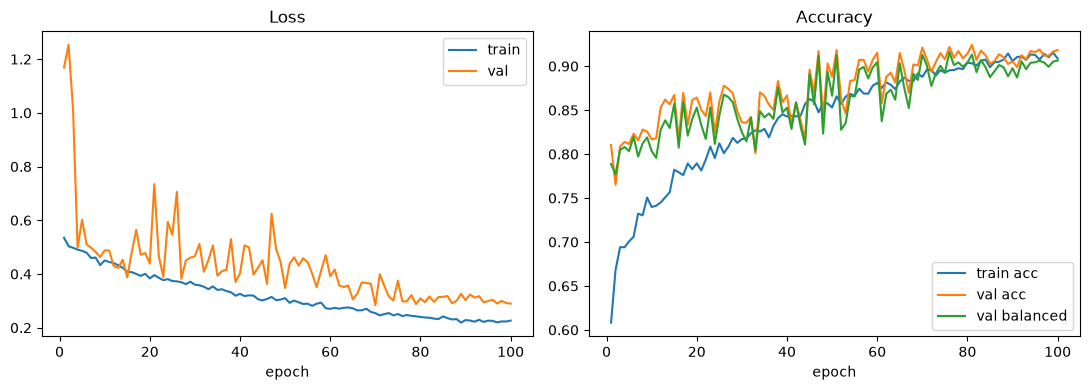

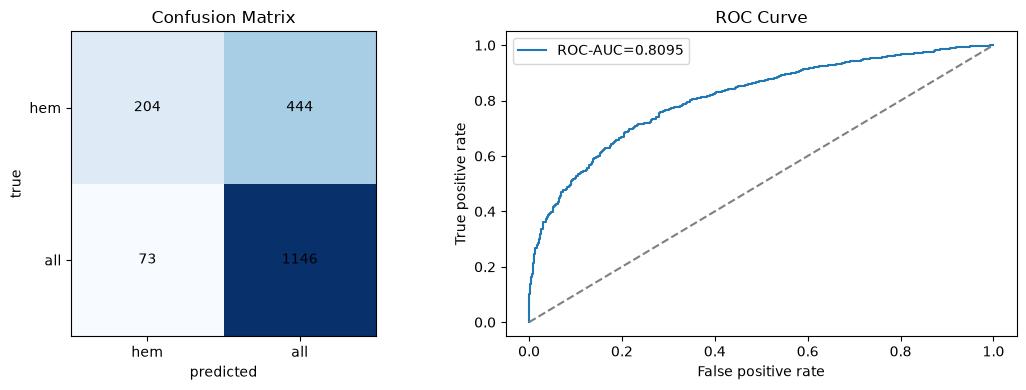

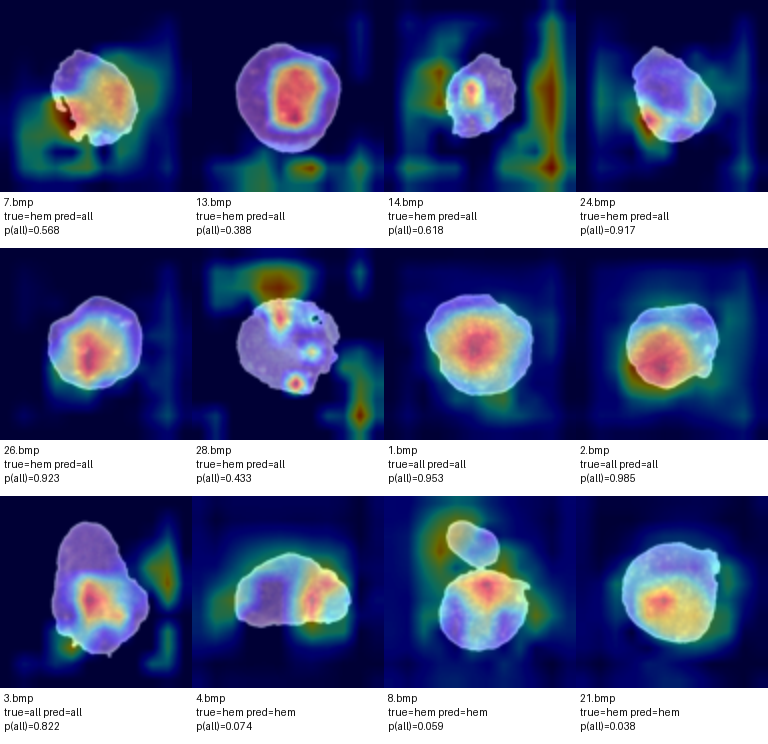

Saved outputs in: /Users/panshulaj/Documents/AIML proj/results/kaggle_compact_resnet_cnn_gnn_100ep
Grad-CAM contact sheet: /Users/panshulaj/Documents/AIML proj/results/kaggle_compact_resnet_cnn_gnn_100ep/gradcam_contact_sheet.png


In [7]:
OUT_DIR = PROJECT_ROOT / "results" / "kaggle_compact_resnet_cnn_gnn_100ep"
best_model, history_df, test_metrics, predictions = fit_model(model, OUT_DIR)
print(json.dumps(test_metrics, indent=2))
display(pd.Series(test_metrics).to_frame("value"))
print(classification_report(predictions["true_label"], predictions["predicted_label"], target_names=["hem_healthy", "all_leukemia"], zero_division=0))
plot_training_history(history_df, OUT_DIR)
plot_confusion_and_roc(test_metrics, predictions, OUT_DIR)
gradcam_sheet = make_gradcam_sheet(best_model, predictions, OUT_DIR, max_images=12)
print("Saved outputs in:", OUT_DIR)
print("Grad-CAM contact sheet:", gradcam_sheet)



## Notes

- Metrics above are produced by this executed notebook, not typed in manually.
- The final Kaggle testing folder is not scored because this Kaggle archive does not include labels for it.
- `all` is treated as leukemia and `hem` is treated as healthy, matching the training folder names and the validation CSV rows where original filenames end in `_all` or `_hem`.
